<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I


# I.2 Transformação de tensões. Tensões principais. Direções principais.

# Problema 5 <a name="PI25"></a>

Considere o seguinte estado de tensão $\tilde{\sigma}$ (MPa), expresso em coordenadas cartesiandas num referencial
$S(O,x,y,z)$:

\begin{equation*}
\underline{\underline{\sigma}}^\top =
\begin{bmatrix}
3 & -10 & 0 \\
-10  & 0 & 30 \\
0 & 30 & -27
\end{bmatrix}
\end{equation*}

[a)](#A) Determine os invariantes do tensor das tensões.

[b)](#B) Indique os valores principais da tensão pelo método dos invariantes.

[c)](#C) Determine a primeira direcção principal.



## Resolução

###  a) Determine os invariantes do tensor das tensões.<a name="A"></a>
([enunciatum](#PI25))

Os invariantes das tensões $I_i$ ($i=1,2,3$) são determinados por:

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

In [17]:
import numpy as np
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})

def matrizTensoes(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

sij = matrizTensoes(3,-10,0,0,30,-27)
print('Matriz das tensões num dado sistema de coordenadas:\n', sij)

def versor(v1,v2,v3): return np.array([v1,v2,v3])

I1 = np.trace(sij)
print('1º Invariante, I1 :', '{:.2f}'.format(I1))

I2 = 0.5*(np.trace(sij)**2 -np.trace(np.dot(sij,sij)))
print('2º Invariante, I2 :', '{:.2f}'.format(I2))

I3 = np.linalg.det(sij)
print('2º Invariante, I3 :', '{:.2f}'.format(I3))


Matriz das tensões num dado sistema de coordenadas:
 [[  3 -10   0]
 [-10   0  30]
 [  0  30 -27]]
1º Invariante, I1 : -24.00
2º Invariante, I2 : -1081.00
2º Invariante, I3 : -0.00


###  b) Indique os valores principais da tensão pelo método dos invariantes.<a name="B"></a>
([enunciatum](#PI25))

A equação carateristica associada à expressão: $|\sigma_{ji}-\sigma\delta_{ij}| = 0$, é um polinómio de terceiro grau na incógnita $\sigma$:

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

e aonde figuram os invariantes das tensões.


 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [-47.000  23.000  0.000]

  Tensão principal (valor próprio) sI = 23.0
 Tensão principal (valor próprio) sII = 0.0
Tensão principal (valor próprio) sIII = -47.0


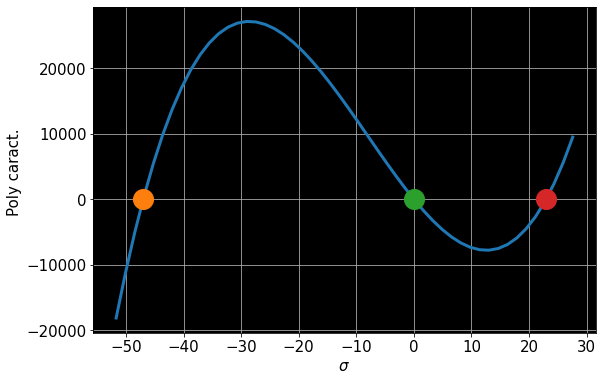

In [18]:
print('\n Resolucao Numerica - Numpy : ............................')
valProp = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valProp)
valProp = np.sort(valProp)
sIII = round(valProp[0])
sII = round(valProp[1])
sI = round(valProp[2])
print('\n  Tensão principal (valor próprio) sI =','{:.1f}'.format(sI))
print(' Tensão principal (valor próprio) sII =','{:.1f}'.format(sII))
print('Tensão principal (valor próprio) sIII =','{:.1f}'.format(sIII))

srange = np.linspace(sIII*1.1,sI*1.2,50)
def polycaract(s):
    return s**3 - I1*s**2 + I2*s - I3

AAA = polycaract(srange)
import matplotlib.pyplot as plt
font = {'size'   : 15}
plt.rc('font', **font)
plt.rcParams['axes.facecolor']='black'
plt.figure(figsize=(9,6))
plt.plot(srange,polycaract(srange),linewidth=3)
for i in valProp:
    plt.plot(i,polycaract(i),'o',markersize=20)
plt.ylabel('Poly caract. ')
plt.xlabel('$\sigma$')
plt.grid('on')
plt.show()

Pelo critério: $\sigma_{\mathrm{I}} > \sigma_{\mathrm{II}} > \sigma_{\mathrm{III}}$, resulta: $\sigma_{\mathrm{I}} = 23$ MPa, $\sigma_{\mathrm{II}} = 0$ MPa e $\sigma_{\mathrm{III}} = -47$ MPa

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =
\begin{bmatrix}
\sigma_{I} & 0 & 0 \\
0 & \sigma_{\mathrm{II}} & 0 \\
0 & 0 & \sigma_{\mathrm{III}}
\end{bmatrix} =
\begin{bmatrix}
23 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -47
\end{bmatrix}
\end{equation*}

Este estado de tensão corresponde a um estado plano de tensão no referencial principal apenas com componentes no plano $xz$.


###  c) Determine a primeira direcção principal.<a name="C"></a>
([enunciatum](#PI25))

Uma vez conhecidas as tensões principais $\sigma_\alpha,~(\alpha= \mathrm{I}, \mathrm{II}, \mathrm{III})$, os respetivos vetores próprios $\vec{n}_\alpha,~(\alpha = \mathrm{I}, \mathrm{II}, \mathrm{III})$ são determinados resolvendo o sistema de equações:

\begin{equation*}
\begin{cases}
(\sigma_{ij} - \sigma_\alpha\delta_{ij}) \cdot n_j  &= 0  \\[1ex]
n_{i} \cdot n_{i} &= 1
\end{cases}
\end{equation*}

A primeira direção principal está associada ao valor próprio de tensão $\sigma_\mathrm{I} = 23$ MPa. Pelo que o vetor principal correspondente vem:

\begin{equation*}
\begin{cases}
(\sigma_{11}-\sigma_\mathrm{I})n_1 + \sigma_{12} n_2  + \sigma_{13} n_3 = 0 \\
\sigma_{21}n_1 + (\sigma_{22}-\sigma_\mathrm{I}) n_2  + \sigma_{23} n_3 = 0 \\
\sigma_{31}n_1 + \sigma_{32} n_2  + (\sigma_{33}-\sigma_\mathrm{I}) n_3 = 0 \\
n_i \cdot n_i = 1
\end{cases}~\Leftrightarrow~
\begin{cases}
(3-23)n_1 - 10 n_2  + 0 = 0 \\
-10 n_1 - 23 n_2  + 30 = 0 \\
0 + 30  + (-27-23) n_3 = 0 \\
n_1^2 + n_2^2 + n_3^2 = 1
\end{cases}
\end{equation*}

resultando,

\begin{equation*}
\vec{n}_{\mathrm{I}} = -0.394\,\vec{e}_1 + 0.788\,\vec{e}_2 + 0.473\,\vec{e}_3
\end{equation*}

De igual forma, se pode obter as componentes cartesianas dos versores próprios (direções principais) $\vec{n}_{\mathrm{II}}$ e $\vec{n}_{\mathrm{III}}$ associados aos valores próprios (às tensões principais) $\sigma_\mathrm{II}$ e $\sigma_\mathrm{III}$, respetivamente.

In [19]:
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (sij[0,0] - vp)*d1 + sij[0,1]*d2 + sij[0,2]*d3
def eq2(d1,d2,d3,vp): return sij[1,0]*d1 + (sij[1,1] - vp)*d2 + sij[1,2]*d3
def eq3(d1,d2,d3,vp): return sij[2,0]*d1 + sij[2,1]*d2 + (sij[2,2] - vp)*d3
def eq4(d1,d2,d3,vp): return d1**2 + d2**2 + d3**2 -1

def valprop(eigv,ind):
    print('(i) Sistema de equações:')
    E11 = eq1(d1,d2,d3,eigv); print(E11,' = 0')
    E21 = eq2(d1,d2,d3,eigv); print(E21,' = 0')
    E31 = eq3(d1,d2,d3,eigv); print(E31,' = 0')
    E41 = eq4(d1,d2,d3,eigv); print(E41,' = 0')
    VetProp1 = solve([E11,E21,E31,E41], [d1,d2,d3], dict=True)
    x1, x2, x3 = float(VetProp1[ind][d1]), float(VetProp1[ind][d2]), float(VetProp1[ind][d3])
    return versor(x1, x2, x3)

# 1 valor proprio -------------------
print('-----------------------------')
print(f'Valor próprio = {sI:.2f} MPa:')
print('-----------------------------')
versprP10 = valprop(sI,0)
versprP11 = valprop(sI,1)
print('===========================================')
print('Vetor próprio : --')
print(f' nI0 = [{versprP10[0]:.3f}, {versprP10[1]:.3f}, '
      f'{versprP10[2]:.3f}]')
print(f' nI1 = [{versprP11[0]:.3f}, {versprP11[1]:.3f}, '
      f'{versprP11[2]:.3f}]')
print('===========================================')


-----------------------------
Valor próprio = 23.00 MPa:
-----------------------------
(i) Sistema de equações:
-20*d1 - 10*d2  = 0
-10*d1 - 23*d2 + 30*d3  = 0
30*d2 - 50*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
(i) Sistema de equações:
-20*d1 - 10*d2  = 0
-10*d1 - 23*d2 + 30*d3  = 0
30*d2 - 50*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
Vetor próprio : --
 nI0 = [-0.394, 0.788, 0.473]
 nI1 = [0.394, -0.788, -0.473]


In [20]:
# 2 valor proprio -------------------
print('\n-----------------------------')
print(f'Valor próprio = {sII:.2f} MPa:')
print('-----------------------------')
versprP20 = valprop(sII,0)
versprP21 = valprop(sII,1)
print('===========================================')
print('Vetor próprio : --')
print(f' nII0 = [{versprP20[0]:.3f}, {versprP20[1]:.3f}, '
      f'{versprP20[2]:.3f}]')
print(f' nII1 = [{versprP21[0]:.3f}, {versprP21[1]:.3f}, '
      f'{versprP21[2]:.3f}]')
print('===========================================')


-----------------------------
Valor próprio = 0.00 MPa:
-----------------------------
(i) Sistema de equações:
3*d1 - 10*d2  = 0
-10*d1 + 30*d3  = 0
30*d2 - 27*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
(i) Sistema de equações:
3*d1 - 10*d2  = 0
-10*d1 + 30*d3  = 0
30*d2 - 27*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
Vetor próprio : --
 nII0 = [-0.912, -0.274, -0.304]
 nII1 = [0.912, 0.274, 0.304]


In [21]:
# 3 valor proprio -------------------
print('\n-----------------------------')
print(f'Valor próprio = {sIII:.2f} MPa:')
print('-----------------------------')
versprP30 = valprop(sIII,0)
versprP31 = valprop(sIII,1)
print('===========================================')
print('Vetor próprio : --')
print(f' nIII0 = [{versprP30[0]:.3f}, {versprP30[1]:.3f}, '
      f'{versprP30[2]:.3f}]')
print(f' nIII1 = [{versprP31[0]:.3f}, {versprP31[1]:.3f}, '
      f'{versprP31[2]:.3f}]')
print('===========================================')


-----------------------------
Valor próprio = -47.00 MPa:
-----------------------------
(i) Sistema de equações:
50*d1 - 10*d2  = 0
-10*d1 + 47*d2 + 30*d3  = 0
30*d2 + 20*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
(i) Sistema de equações:
50*d1 - 10*d2  = 0
-10*d1 + 47*d2 + 30*d3  = 0
30*d2 + 20*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0
Vetor próprio : --
 nIII0 = [-0.110, -0.551, 0.827]
 nIII1 = [0.110, 0.551, -0.827]


In [22]:
print('\n----------------------------------------------------------')
print('Produto misto nI . (nII x nIII) = det([A]) = 1: verificação')
print('----------------------------------------------------------')

from sympy.physics.mechanics import ReferenceFrame, cross, dot
S = ReferenceFrame('S') # ||x|| = ||y|| = ||z|| = 1

print('Escolha 1: ... ')
n1, n2, n3 = versprP10, versprP20, versprP30
syn10 = n1[0]*S.x + n1[1]*S.y + n1[2]*S.z; print(f'vec n1 : {syn10}')
syn20 = n2[0]*S.x + n2[1]*S.y + n2[2]*S.z; print(f'vec n2 : {syn20}')
syn30 = n3[0]*S.x + n3[1]*S.y + n3[2]*S.z; print(f'vec n3 : {syn30}')
basedir0 = dot(syn10,cross(syn20,syn30))
print(f'base direta = {basedir0:.1f}')


----------------------------------------------------------
Produto misto nI . (nII x nIII) = det([A]) = 1: verificação
----------------------------------------------------------
Escolha 1: ... 
vec n1 : - 0.39405520311955*S.x + 0.788110406239101*S.y + 0.47286624374346*S.z
vec n2 : - 0.91244859700871*S.x - 0.273734579102613*S.y - 0.304149532336237*S.z
vec n3 : - 0.110263569283994*S.x - 0.551317846419971*S.y + 0.826976769629957*S.z
base direta = 1.0


In [23]:
print('\nEscolha 2: ...')
n1, n2, n3 = versprP11, versprP21, versprP31
syn11 = n1[0]*S.x + n1[1]*S.y + n1[2]*S.z; print(f'vec n1 : {syn11}')
syn21 = n2[0]*S.x + n2[1]*S.y + n2[2]*S.z; print(f'vec n2 : {syn21}')
syn31 = n3[0]*S.x + n3[1]*S.y + n3[2]*S.z; print(f'vec n3 : {syn31}')
basedir1 = dot(syn11,cross(syn21,syn31))
print(f'base direta = {basedir1:.1f}')


Escolha 2: ...
vec n1 : 0.39405520311955*S.x - 0.788110406239101*S.y - 0.47286624374346*S.z
vec n2 : 0.91244859700871*S.x + 0.273734579102613*S.y + 0.304149532336237*S.z
vec n3 : 0.110263569283994*S.x + 0.551317846419971*S.y - 0.826976769629957*S.z
base direta = -1.0


In [24]:
print('\nEscolha 3: (ver linalg.eig())...')
n1, n2, n3 = versprP11, versprP21, versprP30
syn12 = n1[0]*S.x + n1[1]*S.y + n1[2]*S.z; print(f'vec n1 : {syn12}')
syn22 = n2[0]*S.x + n2[1]*S.y + n2[2]*S.z; print(f'vec n2 : {syn22}')
syn32 = n3[0]*S.x + n3[1]*S.y + n3[2]*S.z; print(f'vec n3 : {syn32}')
basedir2 = dot(syn11,cross(syn22,syn32))
print(f'base direta = {basedir2:.1f}')


Escolha 3: (ver linalg.eig())...
vec n1 : 0.39405520311955*S.x - 0.788110406239101*S.y - 0.47286624374346*S.z
vec n2 : 0.91244859700871*S.x + 0.273734579102613*S.y + 0.304149532336237*S.z
vec n3 : - 0.110263569283994*S.x - 0.551317846419971*S.y + 0.826976769629957*S.z
base direta = 1.0



------------------------
Matriz de transformação
------------------------
Q01 = 
 [[-0.394  0.788  0.473]
 [-0.912 -0.274 -0.304]
 [-0.110 -0.551  0.827]]


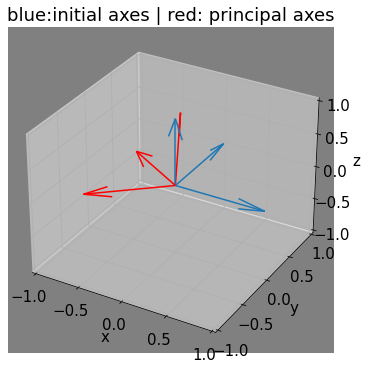

In [25]:
print('\n------------------------')
print('Matriz de transformação')
print('------------------------')

Q01 = np.vstack((versprP10,versprP20,versprP30))
print('Q01 = \n',Q01)

# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

plte1Q = [0,0,0,Q01[0,0],Q01[0,1],Q01[0,2]]
plte2Q = [0,0,0,Q01[1,0],Q01[1,1],Q01[1,2]]
plte3Q = [0,0,0,Q01[2,0],Q01[2,1],Q01[2,2]]
setasQ = np.array([plte1Q, plte2Q, plte3Q])
fig = plt.figure(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
ax = fig.add_subplot(111, projection='3d')
for i in setasQ:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength,
              color='r')
plte1ini = [0,0,0,1,0,0]
plte2ini = [0,0,0,0,1,0]
plte3ini = [0,0,0,0,0,1]
baseini = np.array([plte1ini, plte2ini, plte3ini])
for i in baseini:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
plt.title('blue:initial axes | red: principal axes')
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### Apêndice D. eig()

In [26]:
#eigenvectors and eigenvalues
eig_val, eig_vec = np.linalg.eig(sij)

print('---------------------')
print('vvp - 1 :')
print('---------------------')
print('valor proprio : ',eig_val[0])
print('vetor proprio : ',eig_vec[:,0])
print('---------------------')
print('vvp - 2 :')
print('---------------------')
print('valor proprio : ',eig_val[1])
print('vetor proprio : ',eig_vec[:,1])
print('---------------------')
print('vvp - 3 :')
print('---------------------')
print('valor proprio : ',eig_val[2])
print('vetor proprio : ',eig_vec[:,2])
print('---------------------')
print('sistema coord. ortonormado e direto :')
print('---------------------')
basep = np.transpose(eig_vec)
print('base/eixos principal = \n',basep)

---------------------
vvp - 1 :
---------------------
valor proprio :  22.999999999999993
vetor proprio :  [ 0.394 -0.788 -0.473]
---------------------
vvp - 2 :
---------------------
valor proprio :  1.3783686400219731e-15
vetor proprio :  [ 0.912  0.274  0.304]
---------------------
vvp - 3 :
---------------------
valor proprio :  -47.00000000000001
vetor proprio :  [-0.110 -0.551  0.827]
---------------------
sistema coord. ortonormado e direto :
---------------------
base/eixos principal = 
 [[ 0.394 -0.788 -0.473]
 [ 0.912  0.274  0.304]
 [-0.110 -0.551  0.827]]


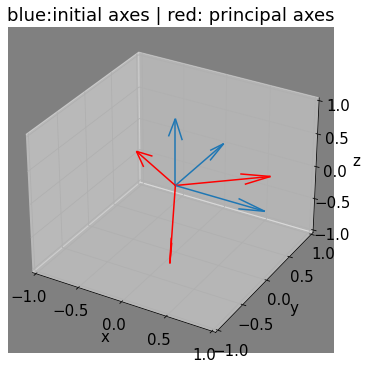

In [27]:
# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

plte1 = [0,0,0,basep[0,0],basep[0,1],basep[0,2]]
plte2 = [0,0,0,basep[1,0],basep[1,1],basep[1,2]]
plte3 = [0,0,0,basep[2,0],basep[2,1],basep[2,2]]
setas = np.array([plte1, plte2, plte3])
fig = plt.figure(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
ax = fig.add_subplot(111, projection='3d')
for i in setas:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength,
              color='r')
for i in baseini:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
plt.title('blue:initial axes | red: principal axes')
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

**Eixos principais (sentidos opostos)**

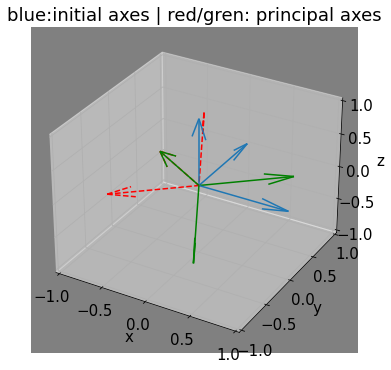

In [28]:
# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

fig = plt.figure(figsize=(9,6))
plt.rcParams['axes.facecolor']='gray'
ax = fig.add_subplot(111, projection='3d')
for i in setasQ:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength,
              color='r', linestyle='--')
for i in setas:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength,
              color='g')
for i in baseini:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
plt.title('blue:initial axes | red/gren: principal axes')
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
